In [314]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import os, warnings
warnings.filterwarnings('ignore')

%matplotlib inline 
plt.rcParams['figure.figsize'] = (12, 4)

In [315]:
def fluff_up_dataframe(df, scale_factor=2.0):
    """
    Fluff up the dataframe by interpolating new datapoints between the existing time points.
    
    Parameters:
    - df: pandas DataFrame with a 'time' column
    - scale_factor: The factor by which to increase the number of datapoints
    
    Returns:
    - New DataFrame with interpolated datapoints.
    """
    
    # Ensure time is sorted
    df = df.sort_values('time').reset_index(drop=True)
    
    # Get the original time range
    original_time = df['time'].values
    
    # Generate the new time points
    new_time = np.linspace(original_time[0], original_time[-1], int(len(original_time) * scale_factor))
    
    # Interpolate the values for each column except 'time'
    interpolated_data = pd.DataFrame({'time': new_time})
    
    for col in df.columns:
        if col != 'time':
            interpolated_data[col] = np.interp(new_time, original_time, df[col].values)
    
    return interpolated_data

In [367]:
# File paths (adjust if needed)
recordings_dir = 'recordings'
time_stamp = '20260425_013116'  # '20260425_013519'
pose_file = f'camera0_{time_stamp}_poses_smoothed.csv'
emg_file = f'emg_data_{time_stamp}.csv'
emg_ts_file = f'emg_timestamps_{time_stamp}.csv'

pose_raw = pd.read_csv(os.path.join(recordings_dir, pose_file))
emg_raw = pd.read_csv(os.path.join(recordings_dir, emg_file))
emg_ts = pd.read_csv(os.path.join(recordings_dir, emg_ts_file))

print("Pose shape:", pose_raw.shape)
print("EMG shape:", emg_raw.shape)
print("EMG timestamps shape:", emg_ts.shape)

Pose shape: (652, 8)
EMG shape: (2400, 8)
EMG timestamps shape: (48, 2)


In [368]:
print("Pose head:")
display(pose_raw[50:60])

print("\nEMG head:")
display(emg_raw.head(10))

print("\nEMG timestamps head:")
display(emg_ts.head(10))

Pose head:


,frame_idx,video_time_s,position_name,source_tag_id,confidence,x,y,z
50,16,0.533333,shoulder,8,66.357000,-0.272574,-0.065348,1.539209
51,17,0.566667,elbow,1,71.938000,-0.159515,0.255374,1.436280
52,17,0.566667,shoulder,8,67.535667,-0.273139,-0.065303,1.539756
53,18,0.600000,elbow,1,71.762333,-0.159815,0.252235,1.427995
54,18,0.600000,shoulder,8,67.121667,-0.273600,-0.065414,1.540261
55,19,0.633333,elbow,1,69.092333,-0.158857,0.247732,1.418220
56,19,0.633333,shoulder,8,67.939333,-0.273844,-0.065690,1.540678
57,20,0.666667,elbow,1,71.146333,-0.156910,0.242724,1.409311
58,20,0.666667,shoulder,8,69.297000,-0.273906,-0.066141,1.541090
59,21,0.700000,elbow,1,72.531667,-0.154467,0.237982,1.402722



EMG head:


,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8
0,0.0,0.0,403.627801,-426.717153,0.0,0.0,0.0,0.0
1,0.0,0.0,404.924203,-426.940671,0.0,0.0,0.0,0.0
2,0.0,0.0,408.120502,-429.354659,0.0,0.0,0.0,0.0
3,0.0,0.0,408.053447,-429.175845,0.0,0.0,0.0,0.0
4,0.0,0.0,406.779397,-428.438238,0.0,0.0,0.0,0.0
5,0.0,0.0,406.779397,-428.549996,0.0,0.0,0.0,0.0
6,0.0,0.0,408.098150,-429.131142,0.0,0.0,0.0,0.0
7,0.0,0.0,406.265307,-429.086438,0.0,0.0,0.0,0.0
8,0.0,0.0,402.197290,-426.448932,0.0,0.0,0.0,0.0
9,0.0,0.0,401.951421,-425.487807,0.0,0.0,0.0,0.0



EMG timestamps head:


,packet_index,pc_time
0,0,1.777099e+09
1,1,1.777099e+09
2,2,1.777099e+09
3,3,1.777099e+09
4,4,1.777099e+09
5,5,1.777099e+09
6,6,1.777099e+09
7,7,1.777099e+09
8,8,1.777099e+09
9,9,1.777099e+09


In [369]:
# We want one row per frame with all three body points.
# Pivot first to see missing pattern, then interpolate.

# 1. Pivot to wide format (same as before, but keep all frames)
pose_wide_raw = pose_raw.pivot_table(index=['frame_idx', 'video_time_s'],
                                     columns='position_name',
                                     values=['x', 'y', 'z'],
                                     aggfunc='mean')
pose_wide_raw.columns = [f'{pos}_{coord}' for coord, pos in pose_wide_raw.columns]
pose_wide_raw = pose_wide_raw.reset_index()

# 2. Count missing values per frame
missing_per_frame = pose_wide_raw.isna().sum(axis=1)
print(f"Frames with missing values:\n{missing_per_frame.value_counts().sort_index()}")

# 3. For each coordinate column, interpolate linearly over frame index
coord_cols = [c for c in pose_wide_raw.columns if c not in ['frame_idx', 'video_time_s']]
pose_wide = pose_wide_raw.copy()
pose_wide[coord_cols] = pose_wide[coord_cols].interpolate(method='linear', limit_direction='both', axis=0)

# 4. Verify no NaNs remain
remaining_nans = pose_wide.isna().sum().sum()
print(f"Remaining NaNs after interpolation: {remaining_nans}")

display(pose_wide[10:20])

Frames with missing values:
0    186
3     47
Name: count, dtype: int64
Remaining NaNs after interpolation: 0


,frame_idx,video_time_s,bracelet_x,elbow_x,shoulder_x,bracelet_y,elbow_y,shoulder_y,bracelet_z,elbow_z,shoulder_z
10,10,0.333333,0.096946,-0.154263,-0.271949,0.292984,0.258509,-0.066412,1.454333,1.455251,1.539082
11,11,0.366667,0.096668,-0.153747,-0.271972,0.292566,0.256248,-0.066319,1.454759,1.447224,1.539009
12,12,0.400000,0.096242,-0.153349,-0.271899,0.292844,0.254450,-0.066186,1.455839,1.440849,1.538777
13,13,0.433333,0.096153,-0.153480,-0.271806,0.292857,0.254064,-0.065993,1.458423,1.438484,1.538555
14,14,0.466667,0.096346,-0.154447,-0.271834,0.286576,0.255031,-0.065754,1.464321,1.439691,1.538525
15,15,0.500000,0.095797,-0.156173,-0.272093,0.264324,0.256312,-0.065518,1.474947,1.441601,1.538757
16,16,0.533333,0.093131,-0.158112,-0.272574,0.220208,0.256686,-0.065348,1.489375,1.441003,1.539209
17,17,0.566667,0.092603,-0.159515,-0.273139,0.214113,0.255374,-0.065303,1.490858,1.436280,1.539756
18,18,0.600000,0.092075,-0.159815,-0.273600,0.208018,0.252235,-0.065414,1.492341,1.427995,1.540261
19,19,0.633333,0.091547,-0.158857,-0.273844,0.201922,0.247732,-0.065690,1.493824,1.418220,1.540678


In [370]:
def resolve_sign(candidates_func, prev_val):
    """
    candidates_func returns two possible angle values (in radians).
    Pick the one closest (circularly) to prev_val.
    """
    val1, val2 = candidates_func()
    # Wrap to [-pi, pi)
    val1 = np.arctan2(np.sin(val1), np.cos(val1))
    val2 = np.arctan2(np.sin(val2), np.cos(val2))
    
    # Circular difference to prev_val
    diff1 = np.abs(np.arctan2(np.sin(val1 - prev_val), np.cos(val1 - prev_val)))
    diff2 = np.abs(np.arctan2(np.sin(val2 - prev_val), np.cos(val2 - prev_val)))
    
    return val1 if diff1 <= diff2 else val2

L1_FIXED = 14 * 0.0254    # 0.3556 m (measured upper arm)
L2_FIXED = 10 * 0.0254    # 0.254 m (measured forearm)

def compute_joint_angles_from_data(pose_df, L1=L1_FIXED):
    x1 = pose_df['elbow_x'] - pose_df['shoulder_x']
    y1 = pose_df['elbow_y'] - pose_df['shoulder_y']
    z1 = pose_df['elbow_z'] - pose_df['shoulder_z']
    
    x2 = pose_df['bracelet_x'] - pose_df['shoulder_x']
    y2 = pose_df['bracelet_y'] - pose_df['shoulder_y']
    z2 = pose_df['bracelet_z'] - pose_df['shoulder_z']
    
    n = len(pose_df)
    q1 = np.zeros(n); q2 = np.zeros(n); q3 = np.zeros(n); q4 = np.zeros(n)
    
    prev_q1, prev_q2, prev_q3, prev_q4 = 0.0, np.pi/2, 0.0, np.pi/2
    
    for i in range(n):
        base_q1 = np.arctan2(y1.iloc[i], x1.iloc[i])
        q1[i] = resolve_sign(lambda: (base_q1, np.arctan2(-y1.iloc[i], x1.iloc[i])), prev_q1)
        
        r_xy = np.sqrt(x1.iloc[i]**2 + y1.iloc[i]**2)
        q2[i] = resolve_sign(lambda: (np.arctan2(r_xy, z1.iloc[i]), np.arctan2(-r_xy, z1.iloc[i])), prev_q2)
        
        c1, s1 = np.cos(q1[i]), np.sin(q1[i])
        c2, s2 = np.cos(q2[i]), np.sin(q2[i])
        B1 = x2.iloc[i]*c1*c2 + y2.iloc[i]*s1*c2 - z2.iloc[i]*s2
        B2 = -x2.iloc[i]*c1*s2 - y2.iloc[i]*s1*s2 - z2.iloc[i]*c2
        B3 = -x2.iloc[i]*s1 + y2.iloc[i]*c1
        
        q3[i] = resolve_sign(lambda: (np.arctan2(B3, B1), np.arctan2(-B3, B1)), prev_q3)
        
        # q4: forearm projection onto -u is (B2 + L1), not (B2 - L1)
        r_B = np.sqrt(B1**2 + B3**2)
        q4[i] = resolve_sign(lambda: (np.arctan2(r_B, B2 + L1), np.arctan2(-r_B, B2 + L1)), prev_q4)
        
        prev_q1, prev_q2, prev_q3, prev_q4 = q1[i], q2[i], q3[i], q4[i]
    
    return pd.DataFrame({
        'video_time_s': pose_df['video_time_s'],
        'q1': q1, 'q2': q2, 'q3': q3, 'q4': q4
    })

joint_angles = compute_joint_angles_from_data(pose_wide)
display(joint_angles.head())

,video_time_s,q1,q2,q3,q4
0,0.000000,1.216233,1.855645,-1.802627,2.036573
1,0.033333,1.218861,1.837837,-1.762627,2.040606
2,0.066667,1.221018,1.823196,-1.729515,2.042865
3,0.100000,1.222638,1.812244,-1.705152,2.043366
4,0.133333,1.224090,1.802405,-1.684415,2.042075


In [371]:
# Use fixed link lengths from a robust estimate (median is more stable than mean)

def forward_kinematics_fixed(q1, q2, q3, q4, L1=L1_FIXED, L2=L2_FIXED):
    """
    Matches the IK convention in compute_joint_angles_fixed_L:
      - Upper-arm frame {e1, e2, -u} where u = shoulder->elbow direction
      - Forearm direction = cos(q4)*(-u) + sin(q4)*(cos(q3)*e1 + sin(q3)*e2)
      - q4 = 0 means forearm folded back along upper arm (elbow fully bent)
      - q4 = pi means forearm extended straight out from upper arm
    """
    c1, s1 = np.cos(q1), np.sin(q1)
    c2, s2 = np.cos(q2), np.sin(q2)
    c3, s3 = np.cos(q3), np.sin(q3)
    c4, s4 = np.cos(q4), np.sin(q4)
    
    # Upper arm direction and elbow position
    u = np.array([s2*c1, s2*s1, c2])
    elbow = L1 * u
    
    # Upper-arm frame, matching IK exactly
    e1 = np.array([c1*c2, s1*c2, -s2])
    e2 = np.array([-s1, c1, 0.0])
    # (No gimbal-lock branch needed: e2 here is well-defined for all q1, q2;
    #  it's the IK's convention, not the spherical-tangent one.)
    
    # Forearm direction — note the MINUS sign on u, matching the IK
    forearm_dir = -c4*u + s4*(c3*e1 + s3*e2)
    
    wrist = elbow + L2 * forearm_dir
    return elbow, wrist

# Sanity check on frame 10
test_frame = 10
row = joint_angles.iloc[test_frame]
elbow_recon, wrist_recon = forward_kinematics_fixed(row.q1, row.q2, row.q3, row.q4)

original = pose_wide.iloc[test_frame]
orig_elb = np.array([original['elbow_x'] - original['shoulder_x'],
                     original['elbow_y'] - original['shoulder_y'],
                     original['elbow_z'] - original['shoulder_z']])
orig_wrs = np.array([original['bracelet_x'] - original['shoulder_x'],
                     original['bracelet_y'] - original['shoulder_y'],
                     original['bracelet_z'] - original['shoulder_z']])

print(f"Frame {test_frame} (fixed link lengths L1={L1_FIXED:.3f}, L2={L2_FIXED:.3f}):")
print(f"  Elbow error: {np.linalg.norm(elbow_recon - orig_elb)*100:.2f} cm")
print(f"  Wrist error: {np.linalg.norm(wrist_recon - orig_wrs)*100:.2f} cm")
print("  (Nonzero errors are expected — they reflect how much the per-frame")
print("   link lengths deviate from the fixed median.)")

# Check across all frames — no more freak-outs
errs_elb = []
errs_wrs = []
for i in range(len(joint_angles)):
    r = joint_angles.iloc[i]
    e_rec, w_rec = forward_kinematics_fixed(r.q1, r.q2, r.q3, r.q4)
    o = pose_wide.iloc[i]
    e_orig = np.array([o['elbow_x']-o['shoulder_x'], o['elbow_y']-o['shoulder_y'], o['elbow_z']-o['shoulder_z']])
    w_orig = np.array([o['bracelet_x']-o['shoulder_x'], o['bracelet_y']-o['shoulder_y'], o['bracelet_z']-o['shoulder_z']])
    errs_elb.append(np.linalg.norm(e_rec - e_orig))
    errs_wrs.append(np.linalg.norm(w_rec - w_orig))

print(f"\nAcross all frames:")
print(f"  Elbow error  — median: {np.median(errs_elb)*100:.2f} cm, max: {max(errs_elb)*100:.2f} cm")
print(f"  Wrist error  — median: {np.median(errs_wrs)*100:.2f} cm, max: {max(errs_wrs)*100:.2f} cm")

Frame 10 (fixed link lengths L1=0.356, L2=0.254):
  Elbow error: 0.00 cm
  Wrist error: 0.04 cm
  (Nonzero errors are expected — they reflect how much the per-frame
   link lengths deviate from the fixed median.)

Across all frames:
  Elbow error  — median: 0.00 cm, max: 0.00 cm
  Wrist error  — median: 1.69 cm, max: 6.67 cm


In [372]:
import numpy as np
import pandas as pd

def diagnose_fk_ik(pose_df, joint_angles, L1_fixed=L1_FIXED, L2_fixed=L2_FIXED):
    """
    Run a battery of tests to localize where the IK/FK mismatch is.
    """
    n = len(joint_angles)
    
    # Per-frame ground truth in shoulder frame
    elb_true = np.column_stack([
        pose_df['elbow_x'] - pose_df['shoulder_x'],
        pose_df['elbow_y'] - pose_df['shoulder_y'],
        pose_df['elbow_z'] - pose_df['shoulder_z'],
    ])
    wrs_true = np.column_stack([
        pose_df['bracelet_x'] - pose_df['shoulder_x'],
        pose_df['bracelet_y'] - pose_df['shoulder_y'],
        pose_df['bracelet_z'] - pose_df['shoulder_z'],
    ])
    
    # Per-frame measured lengths
    L1_meas = np.linalg.norm(elb_true, axis=1)
    forearm_true = wrs_true - elb_true
    L2_meas = np.linalg.norm(forearm_true, axis=1)
    
    print("=== LINK LENGTH SANITY CHECK ===")
    print(f"L1 measured: mean={L1_meas.mean():.4f} m, std={L1_meas.std():.4f}, "
          f"min={L1_meas.min():.4f}, max={L1_meas.max():.4f}")
    print(f"L1 fixed:    {L1_fixed:.4f} m  (= {L1_fixed/0.0254:.2f} inches)")
    print(f"L2 measured: mean={L2_meas.mean():.4f} m, std={L2_meas.std():.4f}, "
          f"min={L2_meas.min():.4f}, max={L2_meas.max():.4f}")
    print(f"L2 fixed:    {L2_fixed:.4f} m  (= {L2_fixed/0.0254:.2f} inches)")
    print(f"L1 ratio (fixed/measured): mean {L1_fixed/L1_meas.mean():.3f}")
    print(f"L2 ratio (fixed/measured): mean {L2_fixed/L2_meas.mean():.3f}")
    
    # Run FK on every frame, collect intermediates
    elb_rec = np.zeros_like(elb_true)
    wrs_rec_fixed = np.zeros_like(wrs_true)   # FK with fixed L2
    wrs_rec_meas  = np.zeros_like(wrs_true)   # FK with measured L2 (isolates length effect)
    forearm_rec_unit = np.zeros_like(wrs_true)
    
    for i in range(n):
        q1, q2, q3, q4 = joint_angles.iloc[i][['q1','q2','q3','q4']]
        c1, s1 = np.cos(q1), np.sin(q1)
        c2, s2 = np.cos(q2), np.sin(q2)
        c3, s3 = np.cos(q3), np.sin(q3)
        c4, s4 = np.cos(q4), np.sin(q4)
        
        u  = np.array([s2*c1, s2*s1, c2])
        e1 = np.array([c1*c2, s1*c2, -s2])
        e2 = np.array([-s1,    c1,    0.0])
        
        elb_rec[i] = L1_fixed * u
        f_dir = -c4*u + s4*(c3*e1 + s3*e2)   # current FK convention
        forearm_rec_unit[i] = f_dir
        wrs_rec_fixed[i] = elb_rec[i] + L2_fixed * f_dir
        wrs_rec_meas[i]  = elb_rec[i] + L2_meas[i] * f_dir
    
    # Errors
    elb_err = np.linalg.norm(elb_rec - elb_true, axis=1)
    wrs_err_fixed = np.linalg.norm(wrs_rec_fixed - wrs_true, axis=1)
    wrs_err_meas  = np.linalg.norm(wrs_rec_meas  - wrs_true, axis=1)
    
    print("\n=== ELBOW vs WRIST RECONSTRUCTION ERRORS ===")
    print(f"Elbow err (fixed L1):           median {np.median(elb_err)*100:.2f} cm, max {elb_err.max()*100:.2f} cm")
    print(f"Wrist err (fixed L1, fixed L2): median {np.median(wrs_err_fixed)*100:.2f} cm, max {wrs_err_fixed.max()*100:.2f} cm")
    print(f"Wrist err (fixed L1, meas L2):  median {np.median(wrs_err_meas)*100:.2f} cm, max {wrs_err_meas.max()*100:.2f} cm")
    print("  ^ If 'meas L2' is much smaller than 'fixed L2', the issue is link-length mismatch.")
    print("    If they're similar, the issue is in the forearm DIRECTION (q3/q4 convention).")
    
    # Forearm direction comparison: this is the key test
    forearm_true_unit = forearm_true / L2_meas[:, None]
    cos_angle = np.sum(forearm_rec_unit * forearm_true_unit, axis=1)
    cos_angle = np.clip(cos_angle, -1, 1)
    angle_err_deg = np.degrees(np.arccos(cos_angle))
    
    print("\n=== FOREARM DIRECTION ERROR (the critical test) ===")
    print(f"Angle between reconstructed and true forearm direction:")
    print(f"  median {np.median(angle_err_deg):.2f}°, mean {angle_err_deg.mean():.2f}°, "
          f"max {angle_err_deg.max():.2f}°")
    print("  Interpretation:")
    print("    < 5°    : direction is correct, residual error is link-length only")
    print("    ~90°    : forearm direction is perpendicular (q3 or q4 convention off)")
    print("    ~180°   : forearm direction is FLIPPED (sign error on u, or q4 inverted)")
    print("    other   : more complex frame mismatch")
    
    # Check the sign-flip hypothesis specifically: try flipping the forearm direction
    wrs_rec_flip = elb_rec - L2_fixed * forearm_rec_unit
    wrs_err_flip = np.linalg.norm(wrs_rec_flip - wrs_true, axis=1)
    print(f"\n=== SIGN-FLIP TEST ===")
    print(f"If we negate the forearm direction:")
    print(f"  Wrist err: median {np.median(wrs_err_flip)*100:.2f} cm, max {wrs_err_flip.max()*100:.2f} cm")
    print("  If this is much smaller, the FK has a sign error on the forearm direction.")
    
    # Try the OTHER convention (positive u instead of negative u) as a sanity check
    wrs_rec_alt = np.zeros_like(wrs_true)
    forearm_alt_unit = np.zeros_like(wrs_true)
    for i in range(n):
        q1, q2, q3, q4 = joint_angles.iloc[i][['q1','q2','q3','q4']]
        c1, s1 = np.cos(q1), np.sin(q1)
        c2, s2 = np.cos(q2), np.sin(q2)
        c3, s3 = np.cos(q3), np.sin(q3)
        c4, s4 = np.cos(q4), np.sin(q4)
        u  = np.array([s2*c1, s2*s1, c2])
        e1 = np.array([c1*c2, s1*c2, -s2])
        e2 = np.array([-s1,    c1,    0.0])
        f_dir_alt = c4*u + s4*(c3*e1 + s3*e2)   # +u instead of -u
        forearm_alt_unit[i] = f_dir_alt
        wrs_rec_alt[i] = L1_fixed*u + L2_fixed * f_dir_alt
    cos_alt = np.clip(np.sum(forearm_alt_unit * forearm_true_unit, axis=1), -1, 1)
    angle_alt_deg = np.degrees(np.arccos(cos_alt))
    print(f"\n=== ALTERNATIVE CONVENTION (+u instead of -u) ===")
    print(f"Forearm angle error: median {np.median(angle_alt_deg):.2f}°, max {angle_alt_deg.max():.2f}°")
    
    # What does the IK actually solve for? Reconstruct B1, B2, B3 and check.
    print("\n=== IK INTERNAL CONSISTENCY (B1, B2, B3 vs forearm projections) ===")
    # The IK computes B = R(q1,q2)^T * wrist_world
    # In the IK's frame: B1 should be wrist · e1, B2 should be wrist · (-u), B3 should be wrist · e2
    # Let's check.
    sample = min(5, n)
    for i in range(sample):
        q1, q2 = joint_angles.iloc[i][['q1','q2']]
        c1, s1 = np.cos(q1), np.sin(q1)
        c2, s2 = np.cos(q2), np.sin(q2)
        u  = np.array([s2*c1, s2*s1, c2])
        e1 = np.array([c1*c2, s1*c2, -s2])
        e2 = np.array([-s1,    c1,    0.0])
        w = wrs_true[i]
        B1 = w @ e1
        B2 = w @ (-u)   # IK's B2 sign convention
        B3 = w @ e2
        # IK's q3, q4 from these:
        q3_ik = np.arctan2(B3, B1)
        q4_ik = np.arctan2(np.sqrt(B1**2+B3**2), B2 - L1_fixed)
        q3_actual, q4_actual = joint_angles.iloc[i][['q3','q4']]
        print(f"  Frame {i}: B=({B1:+.3f},{B2:+.3f},{B3:+.3f})  "
              f"q3 IK-derived={q3_ik:+.3f} actual={q3_actual:+.3f}  "
              f"q4 IK-derived={q4_ik:+.3f} actual={q4_actual:+.3f}")

diagnose_fk_ik(pose_wide, joint_angles)

=== LINK LENGTH SANITY CHECK ===
L1 measured: mean=0.3556 m, std=0.0000, min=0.3556, max=0.3556
L1 fixed:    0.3556 m  (= 14.00 inches)
L2 measured: mean=0.2741 m, std=0.0237, min=0.2354, max=0.3207
L2 fixed:    0.2540 m  (= 10.00 inches)
L1 ratio (fixed/measured): mean 1.000
L2 ratio (fixed/measured): mean 0.927

=== ELBOW vs WRIST RECONSTRUCTION ERRORS ===
Elbow err (fixed L1):           median 0.00 cm, max 0.00 cm
Wrist err (fixed L1, fixed L2): median 1.69 cm, max 6.67 cm
Wrist err (fixed L1, meas L2):  median 0.00 cm, max 0.00 cm
  ^ If 'meas L2' is much smaller than 'fixed L2', the issue is link-length mismatch.
    If they're similar, the issue is in the forearm DIRECTION (q3/q4 convention).

=== FOREARM DIRECTION ERROR (the critical test) ===
Angle between reconstructed and true forearm direction:
  median 0.00°, mean 0.00°, max 0.00°
  Interpretation:
    < 5°    : direction is correct, residual error is link-length only
    ~90°    : forearm direction is perpendicular (q3 or 

In [373]:
import plotly.graph_objects as go
import numpy as np
import matplotlib.colors as mcolors

class ArmVisualizer:
    def __init__(self, fk_func=None, L1=None, L2=None, scene_bounds=(-0.8, 0.8)):
        self.fk_func = fk_func
        self.L1 = L1
        self.L2 = L2
        self.scene_bounds = scene_bounds
        self._traces = []
        self._n_frames = None

    def _to_hex(self, color):
        """Convert any matplotlib color to hex string."""
        try:
            return mcolors.to_hex(color)
        except ValueError:
            return color

    def _to_rgb(self, color):
        """Convert any color to (r,g,b) tuple 0-255."""
        hex_color = self._to_hex(color).lstrip('#')
        return int(hex_color[0:2], 16), int(hex_color[2:4], 16), int(hex_color[4:6], 16)

    def _blend_color(self, base_color, tint_color, factor=0.2):
        """
        Blend base_color with tint_color.
        factor=0.0 → pure base_color
        factor=1.0 → pure tint_color
        """
        br, bg, bb = self._to_rgb(base_color)
        tr, tg, tb = self._to_rgb(tint_color)
        r = int(br + (tr - br) * factor)
        g = int(bg + (tg - bg) * factor)
        b = int(bb + (tb - bb) * factor)
        return f'#{r:02x}{g:02x}{b:02x}'

    def add_arm(self, name, color='orange', dash='solid', width=4,
                q1=None, q2=None, q3=None, q4=None, L1=None, L2=None,
                elbow=None, wrist=None):
        if q1 is not None:
            if self.fk_func is None:
                raise ValueError("You must supply fk_func in constructor to use FK arms.")
            L1 = L1 if L1 is not None else self.L1
            L2 = L2 if L2 is not None else self.L2
            if L1 is None or L2 is None:
                raise ValueError("L1 and L2 must be given either here or in constructor.")
            q1 = np.atleast_1d(q1); q2 = np.atleast_1d(q2)
            q3 = np.atleast_1d(q3); q4 = np.atleast_1d(q4)
            frames = []
            for i in range(len(q1)):
                elb, wri = self.fk_func(q1[i], q2[i], q3[i], q4[i], L1, L2)
                frames.append((np.asarray(elb), np.asarray(wri)))
        elif elbow is not None and wrist is not None:
            elbow = np.atleast_2d(elbow) if np.ndim(elbow) == 1 else np.asarray(elbow)
            wrist = np.atleast_2d(wrist) if np.ndim(wrist) == 1 else np.asarray(wrist)
            frames = [(elbow[i], wrist[i]) for i in range(len(elbow))]
        else:
            raise ValueError("Provide joint angles (q1..q4) or elbow+wrist positions.")

        n = len(frames)
        if self._n_frames is None:
            self._n_frames = n
        elif n == 1:
            frames = frames * self._n_frames
        elif n != self._n_frames:
            raise ValueError(f"Frame count mismatch: {n} vs {self._n_frames}")

        # Standard anatomical colors, lightly tinted with the arm's color
        blend = 0.2
        joint_colors = [
            self._blend_color('#000000', color, factor=blend),   # shoulder: black + tint
            self._blend_color('#3366cc', color, factor=blend),   # elbow: blue + tint
            self._blend_color('#cc3333', color, factor=blend),   # wrist: red + tint
        ]

        self._traces.append(dict(name=name, color=color, dash=dash, width=width,
                                 joint_colors=joint_colors, frames=frames))
        return self

    def show(self, times=None):
        if not self._traces:
            print("No arms added.")
            return
        n = self._n_frames
        if times is None:
            times = list(range(n))
        elif len(times) != n:
            raise ValueError("times length must match frame count")

        fig = go.Figure()
        for tr in self._traces:
            elb, wri = tr['frames'][0]
            fig.add_trace(go.Scatter3d(
                x=[0, elb[0], wri[0]], y=[0, elb[1], wri[1]], z=[0, elb[2], wri[2]],
                mode='lines+markers',
                marker=dict(size=6, color=tr['joint_colors']),
                line=dict(color=tr['color'], width=tr['width'], dash=tr['dash']),
                name=tr['name']))

        plot_frames = []
        for i in range(n):
            traces = []
            for tr in self._traces:
                elb, wri = tr['frames'][i]
                traces.append(go.Scatter3d(
                    x=[0, elb[0], wri[0]], y=[0, elb[1], wri[1]], z=[0, elb[2], wri[2]],
                    mode='lines+markers',
                    marker=dict(size=6, color=tr['joint_colors']),
                    line=dict(color=tr['color'], width=tr['width'], dash=tr['dash']),
                    showlegend=False))
            plot_frames.append(go.Frame(data=traces, name=f'frame{i}'))
        fig.frames = plot_frames

        b = self.scene_bounds
        fig.update_layout(
            scene=dict(xaxis_title='X (m)', yaxis_title='Y (m)', zaxis_title='Z (m)',
                       aspectmode='cube', xaxis_range=[b[0], b[1]],
                       yaxis_range=[b[0], b[1]], zaxis_range=[b[0], b[1]]),
            updatemenus=[dict(type='buttons',
                              buttons=[dict(label='▶ Play', method='animate',
                                            args=[None, {'frame': {'duration': 50, 'redraw': True},
                                                         'fromcurrent': True}]),
                                       dict(label='⏸ Pause', method='animate',
                                            args=[[None], {'frame': {'duration': 0, 'redraw': False},
                                                           'mode': 'immediate', 'transition': {'duration': 0}}])],
                              direction='left', pad={'r':10, 't':87}, showactive=False,
                              x=0.1, xanchor='right', y=0, yanchor='top')],
            sliders=[dict(active=0, yanchor='top', xanchor='left',
                          currentvalue=dict(font=dict(size=16), prefix='Time: ', visible=True, xanchor='right'),
                          transition=dict(duration=30, easing='cubic-in-out'),
                          pad=dict(b=10, t=50), len=0.9, x=0.1, y=0,
                          steps=[dict(args=[[f'frame{k}'], {'frame': {'duration': 0, 'redraw': True},
                                                            'mode': 'immediate', 'transition': {'duration': 0}}],
                                      label=f'{times[k]:.2f}s', method='animate') for k in range(n)])]
        )
        fig.show(renderer='iframe')

In [374]:
viz = ArmVisualizer(fk_func=forward_kinematics_fixed, L1=L1_FIXED, L2=L2_FIXED)

# Ground truth – elbow/wrist arrays relative to shoulder
gt_elbow = pose_wide[['elbow_x','elbow_y','elbow_z']].values - pose_wide[['shoulder_x','shoulder_y','shoulder_z']].values
gt_wrist = pose_wide[['bracelet_x','bracelet_y','bracelet_z']].values - pose_wide[['shoulder_x','shoulder_y','shoulder_z']].values
viz.add_arm(name='Ground truth', color='green', dash='dash', elbow=gt_elbow, wrist=gt_wrist)

# FK arm from joint angles (all frames)
viz.add_arm(name='FK', color='yellow',
            q1=joint_angles['q1'].values, q2=joint_angles['q2'].values,
            q3=joint_angles['q3'].values, q4=joint_angles['q4'].values)

# Downsample for performance
viz.show(times=joint_angles['video_time_s'])

In [375]:
# Use packet timestamps to get accurate sample period
packet_times = emg_ts['pc_time'].values
num_packets = len(packet_times)

# Total duration from first to last packet start
duration = packet_times[-1] - packet_times[0]
# 50 samples per packet, so total samples = num_packets * 50
total_emg_samples = emg_raw.shape[0]
samples_per_packet = total_emg_samples // num_packets  # should be 50

sample_period = duration / (total_emg_samples - 1)
fs_emg = 1.0 / sample_period

# Create uniformly spaced timestamps
t_emg = packet_times[0] + sample_period * np.arange(total_emg_samples)

print(f"Estimated EMG sampling rate: {fs_emg:.2f} Hz")
print(f"First EMG timestamp: {t_emg[0]:.3f}, last: {t_emg[-1]:.3f}")

Estimated EMG sampling rate: 154.38 Hz
First EMG timestamp: 1777098676.859, last: 1777098692.398


Channels with non-zero variance: ['Channel 3', 'Channel 4', 'Channel 8']
Channels with >5% non-zero samples: ['Channel 3', 'Channel 4']


,Channel 3,Channel 4,time
0,403.627801,-426.717153,1.777099e+09
1,404.924203,-426.940671,1.777099e+09
2,408.120502,-429.354659,1.777099e+09
3,408.053447,-429.175845,1.777099e+09
4,406.779397,-428.438238,1.777099e+09


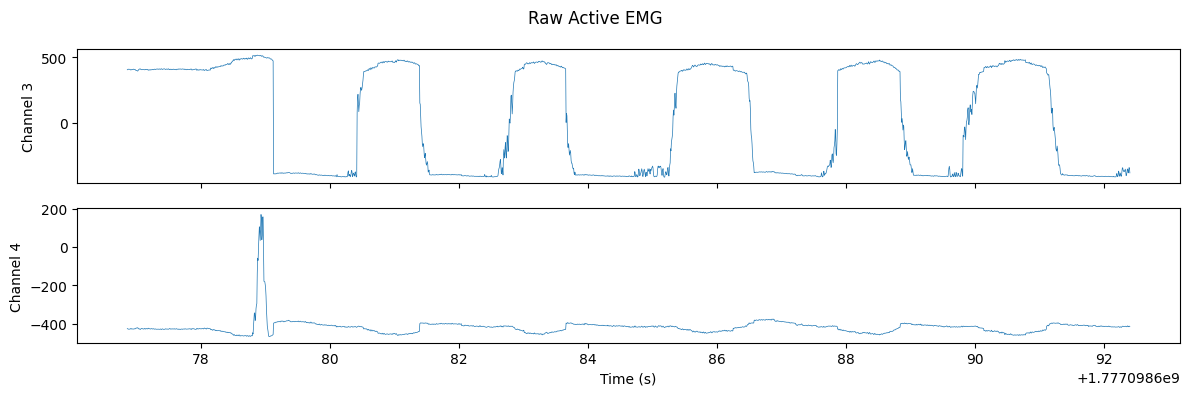

In [376]:
# Require at least 5% of samples to be non-zero to consider a channel truly active
MIN_ACTIVE_FRACTION = 0.05

variances = emg_raw.var()
active_by_var = variances[variances > 1e-6].index.tolist()

# Further filter: must have meaningful non-zero fraction
total_samples = len(emg_raw)
active_channels = []
for ch in emg_raw.columns:
    non_zero_frac = (emg_raw[ch] != 0).sum() / total_samples
    if non_zero_frac >= MIN_ACTIVE_FRACTION:
        active_channels.append(ch)

print(f"Channels with non-zero variance: {active_by_var}")
print(f"Channels with >{MIN_ACTIVE_FRACTION*100:.0f}% non-zero samples: {active_channels}")

emg_active = emg_raw[active_channels].copy()
emg_active['time'] = t_emg

display(emg_active.head())
fig, axes = plt.subplots(len(active_channels), 1, sharex=True, figsize=(12, 2*len(active_channels)))
if len(active_channels) == 1:
    axes = [axes]
for i, ch in enumerate(active_channels):
    axes[i].plot(emg_active['time'], emg_active[ch], linewidth=0.5)
    axes[i].set_ylabel(ch)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('Raw Active EMG')
plt.tight_layout()
plt.show()

In [377]:
# Pose and EMG timestamps are in Unix seconds. We'll use session epoch.
session_epoch = np.floor(packet_times[0])  # integer second of session start

# Convert to relative seconds from session start
pose_time_rel = joint_angles['video_time_s'].values  # already relative to 0
emg_time_rel = t_emg - session_epoch

print(f"Pose time range: {pose_time_rel[0]:.3f} – {pose_time_rel[-1]:.3f} s")
print(f"EMG time range:  {emg_time_rel[0]:.3f} – {emg_time_rel[-1]:.3f} s")

t_min = max(pose_time_rel[0], emg_time_rel[0])
t_max = min(pose_time_rel[-1], emg_time_rel[-1])

# Trim pose
mask_pose = (pose_time_rel >= t_min) & (pose_time_rel <= t_max)
pose_trimmed = joint_angles[mask_pose].copy()
pose_time_trimmed = pose_time_rel[mask_pose]

# Trim EMG
mask_emg = (emg_time_rel >= t_min) & (emg_time_rel <= t_max)
emg_trimmed = emg_active[mask_emg].copy()
emg_time_trimmed = emg_time_rel[mask_emg]

print(f"Overlap interval: {t_min:.3f} – {t_max:.3f} s")
print(f"Pose samples in overlap: {pose_trimmed.shape[0]}")
print(f"EMG samples in overlap: {emg_trimmed.shape[0]}")

Pose time range: 0.000 – 7.733 s
EMG time range:  0.859 – 16.398 s
Overlap interval: 0.859 – 7.733 s
Pose samples in overlap: 207
EMG samples in overlap: 1062


Upsampled joint angles shape: (1062, 5)


,q1,q2,q3,q4,time
0,1.139956,2.015754,-2.061625,1.576703,0.859009
1,1.137884,2.016725,-2.047851,1.537754,0.865486
2,1.135812,2.017695,-2.034076,1.498803,0.871964
3,1.133741,2.018665,-2.020302,1.459854,0.878441
4,1.131669,2.019636,-2.006527,1.420904,0.884919


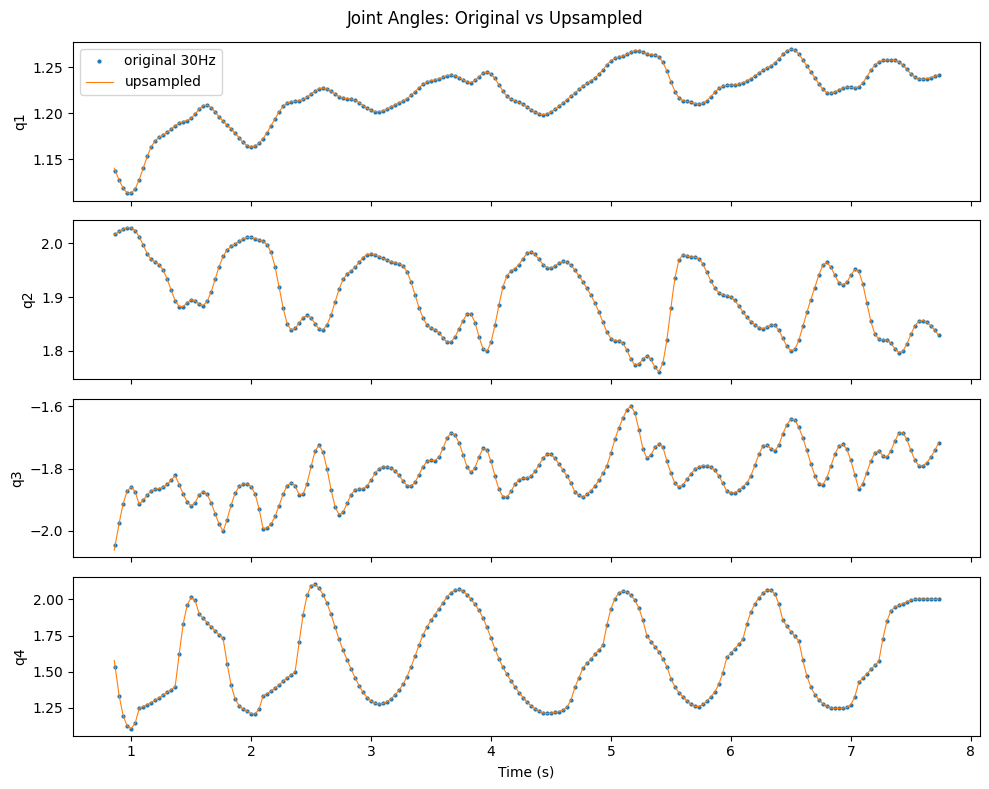

In [378]:
from scipy.interpolate import interp1d

# Build interpolation functions for each angle
interp_funcs = {}
for col in ['q1', 'q2', 'q3', 'q4']:
    interp_funcs[col] = interp1d(pose_time_trimmed, pose_trimmed[col].values,
                                 kind='linear', fill_value='extrapolate')

# Evaluate at EMG timestamps
joint_upsampled = {}
for col in ['q1', 'q2', 'q3', 'q4']:
    joint_upsampled[col] = interp_funcs[col](emg_time_trimmed)

joint_upsampled_df = pd.DataFrame(joint_upsampled)
joint_upsampled_df['time'] = emg_time_trimmed

print("Upsampled joint angles shape:", joint_upsampled_df.shape)
display(joint_upsampled_df.head())
fig, ax = plt.subplots(4, 1, sharex=True, figsize=(10, 8))
for i, col in enumerate(['q1', 'q2', 'q3', 'q4']):
    ax[i].plot(pose_time_trimmed, pose_trimmed[col], 'o', markersize=2, label='original 30Hz')
    ax[i].plot(emg_time_trimmed, joint_upsampled[col], linewidth=0.8, label='upsampled')
    ax[i].set_ylabel(col)
ax[-1].set_xlabel('Time (s)')
fig.suptitle('Joint Angles: Original vs Upsampled')
ax[0].legend()
plt.tight_layout()
plt.show()

# EMG Filtering Stuff

EMG filtered (first 10 rows):


,Channel 3,Channel 4,time
0,403.990066,426.890507,0.859009
1,404.162555,427.019685,0.865486
2,404.308773,427.136790,0.871964
3,404.427295,427.240169,0.878441
4,404.517218,427.328431,0.884919
5,404.578225,427.400501,0.891396
6,404.610612,427.455654,0.897874
7,404.615319,427.493546,0.904351
8,404.593917,427.514232,0.910829
9,404.548593,427.518166,0.917306


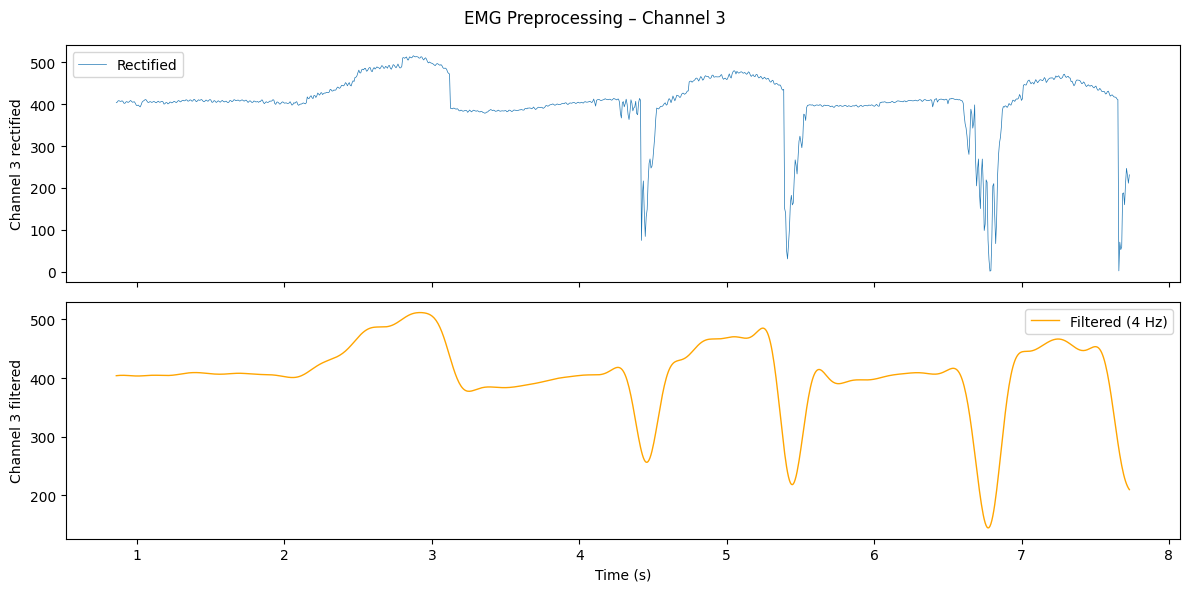

In [379]:
# Rectify
emg_rectified = emg_trimmed[active_channels].abs()

# Design Butterworth low-pass filter (4th order, 4 Hz cutoff)
nyquist = 0.5 * fs_emg
cutoff = 4.0
b, a = butter(4, cutoff / nyquist, btype='low')

# Apply forward-backward (zero-phase) filter
emg_filtered = pd.DataFrame(index=emg_rectified.index)
for ch in active_channels:
    emg_filtered[ch] = filtfilt(b, a, emg_rectified[ch])

emg_filtered['time'] = emg_time_trimmed

print("EMG filtered (first 10 rows):")
display(emg_filtered.head(10))
ch = active_channels[0]  # plot first active channel
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(12, 6))
ax[0].plot(emg_time_trimmed, emg_rectified[ch], linewidth=0.5, label='Rectified')
ax[0].set_ylabel(f'{ch} rectified')
ax[0].legend()

ax[1].plot(emg_time_trimmed, emg_filtered[ch], linewidth=1.0, color='orange', label='Filtered (4 Hz)')
ax[1].set_ylabel(f'{ch} filtered')
ax[1].set_xlabel('Time (s)')
ax[1].legend()
plt.suptitle(f'EMG Preprocessing – {ch}')
plt.tight_layout()
plt.show()

   Channel 3  Channel 4      time
0   0.003092   0.009730  0.612944
1   0.002371   0.007775  0.619553
2   0.001777   0.006232  0.626163
3   0.001305   0.005098  0.632772
4   0.000949   0.004363  0.639382


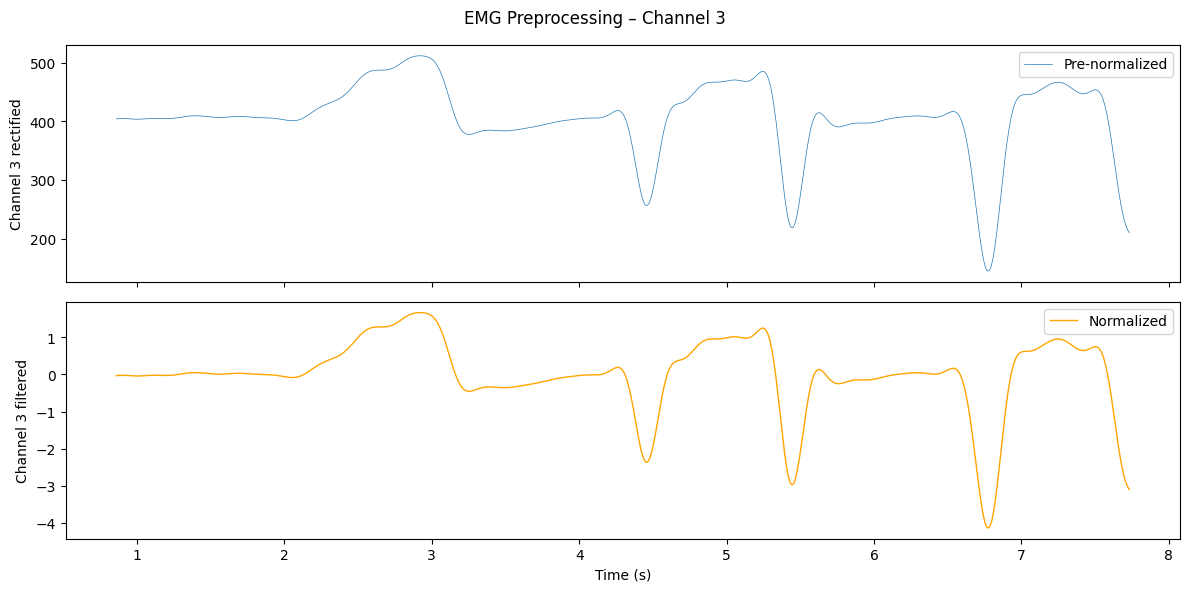

In [380]:
emg_cols = [ch for ch in emg_filtered.columns if ch != 'time']
emg_standardized = emg_filtered.copy()
emg_standardized[emg_cols] = (emg_filtered[emg_cols] - emg_filtered[emg_cols].mean()) / emg_filtered[emg_cols].std()

print(emg_normalized.head())
ch = active_channels[0]  # plot first active channel
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(12, 6))
ax[0].plot(emg_time_trimmed, emg_filtered[ch], linewidth=0.5, label='Pre-normalized')
ax[0].set_ylabel(f'{ch} rectified')
ax[0].legend()

ax[1].plot(emg_time_trimmed, emg_standardized[ch], linewidth=1.0, color='orange', label='Normalized')
ax[1].set_ylabel(f'{ch} filtered')
ax[1].set_xlabel('Time (s)')
ax[1].legend()
plt.suptitle(f'EMG Preprocessing – {ch}')
plt.tight_layout()
plt.show()

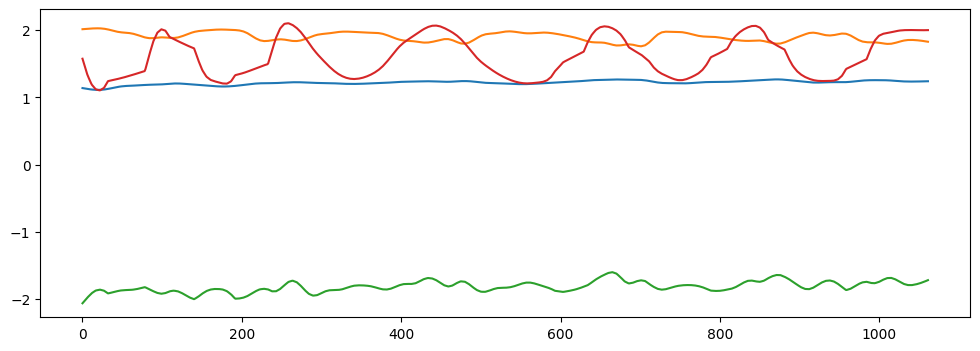

In [381]:
# Also standardize joints

joint_cols = [ch for ch in joint_upsampled_df.columns if ch != 'time']
joint_upsampled_standardized_df = joint_upsampled_df.copy()
joint_upsampled_standardized_df[joint_cols] = (joint_upsampled_df[joint_cols] - joint_upsampled_df[joint_cols].mean()) / joint_upsampled_df[joint_cols].std()
plt.plot(joint_upsampled_df[[f'q{i}' for i in range(1, 5)]])

In [382]:
plt.close()

cols = ['time'] + emg_cols + ['q1', 'q2', 'q3', 'q4']
non_time_cols = emg_cols + ['q1', 'q2', 'q3', 'q4']
df_model = pd.concat([emg_standardized['time'], emg_standardized[emg_cols], joint_upsampled_df[['q1', 'q2', 'q3', 'q4']]], axis=1)

# df_model = fluff_up_dataframe(df_model, 10)

print("Final model-ready dataset shape:", df_model.shape)
display(df_model.head())
print('Check if the mean is close to 0 and the variance close to 1 (except time)')
print('MEAN: \n')
display(df_model[non_time_cols].mean())
print('\n VARIANCE: \n')
display(df_model[non_time_cols].std())
print()

time_diffs = df_model['time'].diff().dropna()
print(time_diffs)
print(f"Time step: {time_diffs.mean():.4f} s ± {time_diffs.std():.6f} s")
print(df_model.head())

Final model-ready dataset shape: (1062, 7)


,time,Channel 3,Channel 4,q1,q2,q3,q4
0,0.859009,-0.032477,0.184631,1.139956,2.015754,-2.061625,1.576703
1,0.865486,-0.029745,0.187432,1.137884,2.016725,-2.047851,1.537754
2,0.871964,-0.027429,0.189972,1.135812,2.017695,-2.034076,1.498803
3,0.878441,-0.025552,0.192214,1.133741,2.018665,-2.020302,1.459854
4,0.884919,-0.024128,0.194128,1.131669,2.019636,-2.006527,1.420904


Check if the mean is close to 0 and the variance close to 1 (except time)
MEAN: 



Channel 3   -4.148178e-16
Channel 4   -8.028731e-16
q1           1.219607e+00
q2           1.901212e+00
q3          -1.814027e+00
q4           1.598267e+00
dtype: float64


 VARIANCE: 



Channel 3    1.000000
Channel 4    1.000000
q1           0.031525
q2           0.067561
q3           0.078489
q4           0.293351
dtype: float64


1       0.006477
2       0.006478
3       0.006477
4       0.006478
5       0.006477
          ...   
1057    0.006477
1058    0.006477
1059    0.006478
1060    0.006477
1061    0.006478
Name: time, Length: 1061, dtype: float64
Time step: 0.0065 s ± 0.000000 s
       time  Channel 3  Channel 4        q1        q2        q3        q4
0  0.859009  -0.032477   0.184631  1.139956  2.015754 -2.061625  1.576703
1  0.865486  -0.029745   0.187432  1.137884  2.016725 -2.047851  1.537754
2  0.871964  -0.027429   0.189972  1.135812  2.017695 -2.034076  1.498803
3  0.878441  -0.025552   0.192214  1.133741  2.018665 -2.020302  1.459854
4  0.884919  -0.024128   0.194128  1.131669  2.019636 -2.006527  1.420904


# Model

In [383]:
"""
Linear State-Space Model with Numba-jitted forward and backward passes.

Model:
    x_{k+1} = A x_k + B u_k
    z_k     = C x_k

Fit by prediction-error minimization with x_0 = 0, using a hand-derived
analytic gradient (reverse-mode through the recursion).
"""
import numpy as np
from numba import njit
from scipy.optimize import minimize

@njit
def _forward(U, A, B, C, x0):
    T = U.shape[0]
    p = C.shape[0]
    d = A.shape[0]
    m = U.shape[1]
    X = np.empty((T, d))
    Z_hat = np.empty((T, p))
    x = x0.copy()
    for k in range(T):
        for i in range(d):
            X[k, i] = x[i]
        for i in range(p):
            s = 0.0
            for j in range(d):
                s += C[i, j] * x[j]
            Z_hat[k, i] = s
        x_new = np.zeros(d)
        for i in range(d):
            s = 0.0
            for j in range(d):
                s += A[i, j] * x[j]
            for j in range(m):
                s += B[i, j] * U[k, j]
            x_new[i] = s
        x = x_new
    return X, Z_hat


@njit
def _backward_accumulate(U, Z, X, Z_hat, A, C, dA, dB, dC, dx0,
                         n_burnin, total_count):
    """
    Accumulate gradients for one episode into provided buffers.
    Skips the first n_burnin timesteps in the loss/gradient.
    Returns sum of squared errors over the SCORED steps.
    """
    T = U.shape[0]
    p = C.shape[0]
    d = A.shape[0]
    m = U.shape[1]
    scale = 2.0 / total_count

    # Residuals: zero out burn-in region so it contributes nothing
    R = np.empty((T, p))
    sse = 0.0
    for k in range(T):
        if k < n_burnin:
            for i in range(p):
                R[k, i] = 0.0
        else:
            for i in range(p):
                r = Z_hat[k, i] - Z[k, i]
                R[k, i] = r
                sse += r * r

    # dC contribution (only scored steps contribute, since R is zero in burn-in)
    for k in range(T):
        for i in range(p):
            for j in range(d):
                dC[i, j] += scale * R[k, i] * X[k, j]

    # Backward adjoint recursion
    lam = np.zeros(d)
    for k in range(T - 1, -1, -1):
        if k < T - 1:
            for i in range(d):
                for j in range(d):
                    dA[i, j] += lam[i] * X[k, j]
                for j in range(m):
                    dB[i, j] += lam[i] * U[k, j]
        new_lam = np.zeros(d)
        for i in range(d):
            s = 0.0
            for j in range(p):
                s += C[j, i] * R[k, j]
            new_lam[i] = scale * s
            for j in range(d):
                new_lam[i] += A[j, i] * lam[j]
        lam = new_lam

    # Gradient w.r.t. x0 is the adjoint at k=0 (after the loop, `lam` holds it)
    for i in range(d):
        dx0[i] += lam[i]

    return sse


@njit
def _step(x, u, A, B, C):
    """Single-step inference: returns (z_k, x_{k+1})."""
    d = A.shape[0]
    p = C.shape[0]
    m = u.shape[0]
    z = np.zeros(p)
    for i in range(p):
        s = 0.0
        for j in range(d):
            s += C[i, j] * x[j]
        z[i] = s
    x_next = np.zeros(d)
    for i in range(d):
        s = 0.0
        for j in range(d):
            s += A[i, j] * x[j]
        for j in range(m):
            s += B[i, j] * u[j]
        x_next[i] = s
    return z, x_next


class LSSM:
    """
    Linear state-space model fit by prediction-error minimization
    with analytic gradients.
    """
    
    def __init__(self, state_dim, input_dim, output_dim):
        self.d = state_dim
        self.m = input_dim
        self.p = output_dim
        self.A = np.zeros((self.d, self.d))
        self.B = np.zeros((self.d, self.m))
        self.C = np.zeros((self.p, self.d))
        self.x0_learned = np.zeros(self.d)
        self.x = np.zeros(self.d)
        # standardization stats
        self.u_mean = np.zeros(self.m)
        self.u_std = np.ones(self.m)
        self.z_mean = np.zeros(self.p)
        self.z_std = np.ones(self.p)

    # ---- Helpers ----------------------------------------------------

    def _init_theta(self, rng, learn_x0):
        """Initialize A with eigenvalues spread around the unit disk,
        favoring slow modes. B, C small."""
        d, m, p = self.d, self.m, self.p
        nA, nB, nC = d*d, d*m, p*d
    
        # Build A as a block-diagonal of 2x2 rotation-scaling blocks at varied
        # frequencies, plus noise. This guarantees a mix of slow and fast modes.
        A0 = np.zeros((d, d))
        n_blocks = d // 2
        # Spread angular frequencies log-uniformly between very-slow and Nyquist/4
        if n_blocks > 0:
            omegas = np.exp(np.linspace(np.log(2*np.pi/2000),
                                        np.log(2*np.pi/8), n_blocks))
            radii = rng.uniform(0.85, 0.98, size=n_blocks)
            for i, (om, r) in enumerate(zip(omegas, radii)):
                c, s = r*np.cos(om), r*np.sin(om)
                A0[2*i, 2*i] = c
                A0[2*i, 2*i+1] = -s
                A0[2*i+1, 2*i] = s
                A0[2*i+1, 2*i+1] = c
        if d % 2 == 1:
            A0[-1, -1] = rng.uniform(0.85, 0.98)
        # Add small noise to break exact block structure
        A0 += 0.01 * rng.standard_normal((d, d))
    
        B0 = 0.1 * rng.standard_normal((d, m))
        C0 = (0.1 / np.sqrt(d)) * rng.standard_normal((p, d))
    
        parts = [A0.ravel(), B0.ravel(), C0.ravel()]
        if learn_x0:
            parts.append(np.zeros(d))
        return np.concatenate(parts)

    # ---- inference ----------------------------------------------------

    def reset(self):
        """Zero the running latent state. Call between independent episodes."""
        self.x = self.x0_learned.copy()
    
    def __call__(self, u, advance=True):
        u = np.ascontiguousarray(np.asarray(u, dtype=np.float64).reshape(self.m))
        u_norm = (u - self.u_mean) / self.u_std
        z, x_next = _step(self.x, u_norm, self.A, self.B, self.C)
        if advance:
            self.x = x_next
        return z * self.z_std + self.z_mean
    
    def predict(self, U):
        U = np.ascontiguousarray(np.asarray(U, dtype=np.float64))
        U_norm = (U - self.u_mean) / self.u_std
        _, Z_hat = _forward(U_norm, self.A, self.B, self.C, self.x0_learned)
        return Z_hat * self.z_std + self.z_mean
        
    # ---- fitting ------------------------------------------------------

    def fit(self, U, Z, n_restarts=1, seed=0,
        n_burnin=0, alpha=0.0, learn_x0=True, standardize=True, n_polish=3):
        """
        U, Z: either single arrays (T, m), (T, p), or lists of episode arrays.
        n_burnin: number of initial timesteps per episode excluded from loss.
        alpha: L2 regularization on A, B, C (not on x0).
        learn_x0: if True, x0 is a learnable parameter shared across episodes.
                  If False, x0 is fixed at zero.
        """
        # Normalize to list of episodes
        if isinstance(U, np.ndarray) and U.ndim == 2:
            U_eps = [np.ascontiguousarray(U, dtype=np.float64)]
            Z_eps = [np.ascontiguousarray(Z, dtype=np.float64)]
        else:
            U_eps = [np.ascontiguousarray(np.asarray(u, dtype=np.float64)) for u in U]
            Z_eps = [np.ascontiguousarray(np.asarray(z, dtype=np.float64)) for z in Z]

        if standardize:
            U_all = np.concatenate(U_eps)
            Z_all = np.concatenate(Z_eps)
            self.u_mean = U_all.mean(axis=0)
            self.u_std = U_all.std(axis=0) + 1e-8
            self.z_mean = Z_all.mean(axis=0)
            self.z_std = Z_all.std(axis=0) + 1e-8
            U_eps = [(u - self.u_mean) / self.u_std for u in U_eps]
            Z_eps = [(z - self.z_mean) / self.z_std for z in Z_eps]
            # else leave the (zeros, ones) defaults from __init__
    
        d, m, p = self.d, self.m, self.p
        nA, nB, nC, nx0 = d*d, d*m, p*d, (d if learn_x0 else 0)
        n_params = nA + nB + nC + nx0
    
        # Total count: only scored timesteps contribute
        total_count = sum(max(0, u.shape[0] - n_burnin) for u in U_eps) * p
        if total_count == 0:
            raise ValueError("n_burnin >= episode lengths; nothing to score.")
    
        def loss_and_grad(theta):
            A = np.ascontiguousarray(theta[:nA].reshape(d, d))
            B = np.ascontiguousarray(theta[nA:nA+nB].reshape(d, m))
            C = np.ascontiguousarray(theta[nA+nB:nA+nB+nC].reshape(p, d))
            if learn_x0:
                x0 = np.ascontiguousarray(theta[nA+nB+nC:])
            else:
                x0 = np.zeros(d)
    
            dA = np.zeros((d, d))
            dB = np.zeros((d, m))
            dC = np.zeros((p, d))
            dx0 = np.zeros(d)
            sse = 0.0
            for U_e, Z_e in zip(U_eps, Z_eps):
                X, Z_hat = _forward(U_e, A, B, C, x0)
                sse += _backward_accumulate(U_e, Z_e, X, Z_hat, A, C,
                                            dA, dB, dC, dx0,
                                            n_burnin, total_count)
            loss = sse / total_count
    
            # L2 regularization on A, B, C only
            if alpha > 0.0:
                loss += alpha * (np.sum(A*A) + np.sum(B*B) + np.sum(C*C))
                dA += 2.0 * alpha * A
                dB += 2.0 * alpha * B
                dC += 2.0 * alpha * C
    
            if learn_x0:
                grad = np.concatenate([dA.ravel(), dB.ravel(), dC.ravel(), dx0])
            else:
                grad = np.concatenate([dA.ravel(), dB.ravel(), dC.ravel()])
    
            if not np.isfinite(loss) or not np.all(np.isfinite(grad)):
                return 1e10, np.zeros_like(grad)
            return loss, grad
        rng = np.random.default_rng(seed)

        # Stage 1: cheap exploration of all restarts
        candidates = []
        for _ in range(n_restarts):
            theta0 = self._init_theta(rng, learn_x0)
            res = minimize(loss_and_grad, theta0, jac=True, method='L-BFGS-B',
                           options={'maxiter': 100, 'ftol': 1e-6, 'gtol': 1e-4})
            if res.x is not None:
                final_loss, _ = loss_and_grad(res.x)
                if np.isfinite(final_loss):
                    candidates.append((final_loss, res.x))

        if not candidates:
            best_theta = self._init_theta(rng, learn_x0)
            print('Warning: no stage-1 candidate succeeded; using random init.')
        else:
            candidates.sort(key=lambda c: c[0])
            k = min(n_polish, len(candidates))
            print(f'Stage 1 top-{k} losses: '
                  f'{[f"{c[0]:.6f}" for c in candidates[:k]]}')

            # Stage 2: polish the top k
            best_loss = np.inf
            best_theta = candidates[0][1]   # fallback to stage-1 best
            for i in range(k):
                _, theta_i = candidates[i]
                res = minimize(loss_and_grad, theta_i, jac=True, method='L-BFGS-B',
                               options={'maxiter': 2000, 'ftol': 1e-10, 'gtol': 1e-8})
                if res.x is not None:
                    final_loss, _ = loss_and_grad(res.x)
                    if final_loss < best_loss:
                        print(f'  Polish {i+1}/{k}: {final_loss:.6f} (new best)')
                        best_loss = final_loss
                        best_theta = res.x
                    else:
                        print(f'  Polish {i+1}/{k}: {final_loss:.6f}')
        if best_theta is None:
            best_theta = theta0
    
        self.A = np.ascontiguousarray(best_theta[:nA].reshape(d, d))
        self.B = np.ascontiguousarray(best_theta[nA:nA+nB].reshape(d, m))
        self.C = np.ascontiguousarray(best_theta[nA+nB:nA+nB+nC].reshape(p, d))
        if learn_x0:
            self.x0_learned = np.ascontiguousarray(best_theta[nA+nB+nC:])
        else:
            self.x0_learned = np.zeros(d)
        self.reset()
        return self

In [384]:
# Cell: PCA (ensure we have the low-dimensional data)
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

emg_cols = [c for c in df_model.columns if c not in ['time','q1','q2','q3','q4']]
joint_cols = ['q4']  # ['q1','q2','q3','q4']

emg_data = df_model[emg_cols].values
joint_data = df_model[joint_cols].values
full_joint_data = df_model[['q1','q2','q3','q4']].values

# Fit PCA
pca_emg = PCA(n_components=2)
pca_joint = PCA(n_components=4)

U_full = emg_data  # pca_emg.fit_transform(emg_data)
Z_full = joint_data  # pca_joint.fit_transform(joint_data)

# Keep just the top 2 for downstream use
U = U_full[:, :]
Z = Z_full[:, :]
# ---------- EMG PCA diagnostics ----------
print("="*60)
print("EMG PCA")
print("="*60)
print(f"Input shape: {emg_data.shape}  (T samples × {len(emg_cols)} channels)")
print(f"Channels: {emg_cols}\n")

print("Explained variance ratio per component:")
for i, ev in enumerate(pca_emg.explained_variance_ratio_):
    print(f"  PC{i+1}: {ev:.4f} ({ev*100:.2f}%)")
print(f"Cumulative (first 2): {pca_emg.explained_variance_ratio_[:2].sum():.4f}")
print(f"Cumulative (all):     {pca_emg.explained_variance_ratio_.sum():.4f}\n")

print("Singular values:", pca_emg.singular_values_)
print("Eigenvalues (variance per PC):", pca_emg.explained_variance_, "\n")

print("Loadings (components_), shape =", pca_emg.components_.shape)
print("Rows = PCs, columns = original EMG channels:")
loadings_emg = pd.DataFrame(
    pca_emg.components_,
    columns=emg_cols,
    index=[f'PC{i+1}' for i in range(pca_emg.n_components_)]
)
print(loadings_emg.round(3), "\n")

print("Mean of each EMG channel (subtracted before PCA):")
print(pd.Series(pca_emg.mean_, index=emg_cols).round(4), "\n")

# ---------- Joint PCA diagnostics ----------
print("="*60)
print("Joint kinematics PCA")
print("="*60)
print(f"Input shape: {joint_data.shape}  (T samples × {len(joint_cols)} joints)")
print(f"Joints: {joint_cols}\n")

print("Explained variance ratio per component:")
for i, ev in enumerate(pca_joint.explained_variance_ratio_):
    print(f"  PC{i+1}: {ev:.4f} ({ev*100:.2f}%)")
print(f"Cumulative (first 2): {pca_joint.explained_variance_ratio_[:2].sum():.4f}")
print(f"Cumulative (all):     {pca_joint.explained_variance_ratio_.sum():.4f}\n")

print("Singular values:", pca_joint.singular_values_)
print("Eigenvalues (variance per PC):", pca_joint.explained_variance_, "\n")

print("Loadings (components_), shape =", pca_joint.components_.shape)
loadings_joint = pd.DataFrame(
    pca_joint.components_,
    columns=joint_cols,
    index=[f'PC{i+1}' for i in range(pca_joint.n_components_)]
)
print(loadings_joint.round(3), "\n")

print("Mean of each joint (subtracted before PCA):")
print(pd.Series(pca_joint.mean_, index=joint_cols).round(4), "\n")

# ---------- Embedding diagnostics ----------
print("="*60)
print("Embeddings")
print("="*60)
print(f"U shape: {U.shape}, Z shape: {Z.shape}")
print(f"U range: [{U.min():.3f}, {U.max():.3f}],  std per col: {U.std(axis=0).round(3)}")
print(f"Z range: [{Z.min():.3f}, {Z.max():.3f}],  std per col: {Z.std(axis=0).round(3)}")

EMG PCA
Input shape: (1062, 2)  (T samples × 2 channels)
Channels: ['Channel 3', 'Channel 4']

Explained variance ratio per component:


AttributeError: 'PCA' object has no attribute 'explained_variance_ratio_'

In [354]:
import cProfile
import io
import pstats

# Profile your function
# profiler = cProfile.Profile()

# Save to file
# LSSM code must be defined above (your provided block)

# Choose state dimension (try 4, increase if needed)
d = 16

model = LSSM(state_dim=d, input_dim=2, output_dim=1)

# Fit (the function will internally use U and Z)
# Fit the model
model.fit(U, Z,
          n_burnin=0,
          n_restarts=10,
          n_polish=3,
          seed=42,
          alpha=1e-5,        # mild L2; prevents A from hugging unit circle
          standardize=True)

Stage 1 top-3 losses: ['0.647047', '0.667981', '0.670168']
  Polish 1/3: 0.404631 (new best)
  Polish 2/3: 0.643645
  Polish 3/3: 0.617225
Training MSE: 0.021347


In [385]:
# Predict and compute loss
Z_hat = model.predict(U)
mse = np.mean((Z_hat - Z) ** 2)
print(f"Training MSE: {mse:.6f}")

Training MSE: 7.389949


In [386]:
'''
import pstats

p = pstats.Stats('profile_output3.prof')
p.strip_dirs()
p.sort_stats('cumulative')
p.print_stats(50)
'''
print()

In [387]:
eigs = np.linalg.eigvals(model.A)
print("Magnitudes:", sorted(np.abs(eigs), reverse=True)[:5])
print("Angles (rad):", sorted([abs(np.angle(e)) for e in eigs], reverse=True)[:5])
print("Periods (samples):", [2*np.pi/abs(np.angle(e)) for e in eigs if abs(np.angle(e)) > 1e-3][:5])

Magnitudes: [np.float64(1.0003402571614932), np.float64(1.0003402571614932), np.float64(0.9996829817782656), np.float64(0.9996829817782656), np.float64(0.9712528055488341)]
Angles (rad): [np.float64(0.7854076300512476), np.float64(0.7854076300512476), np.float64(0.3511397405820277), np.float64(0.3511397405820277), np.float64(0.1587413863238027)]
Periods (samples): [np.float64(7.9999035746184575), np.float64(7.9999035746184575), np.float64(17.8936889819562), np.float64(17.8936889819562), np.float64(39.581267700176596)]


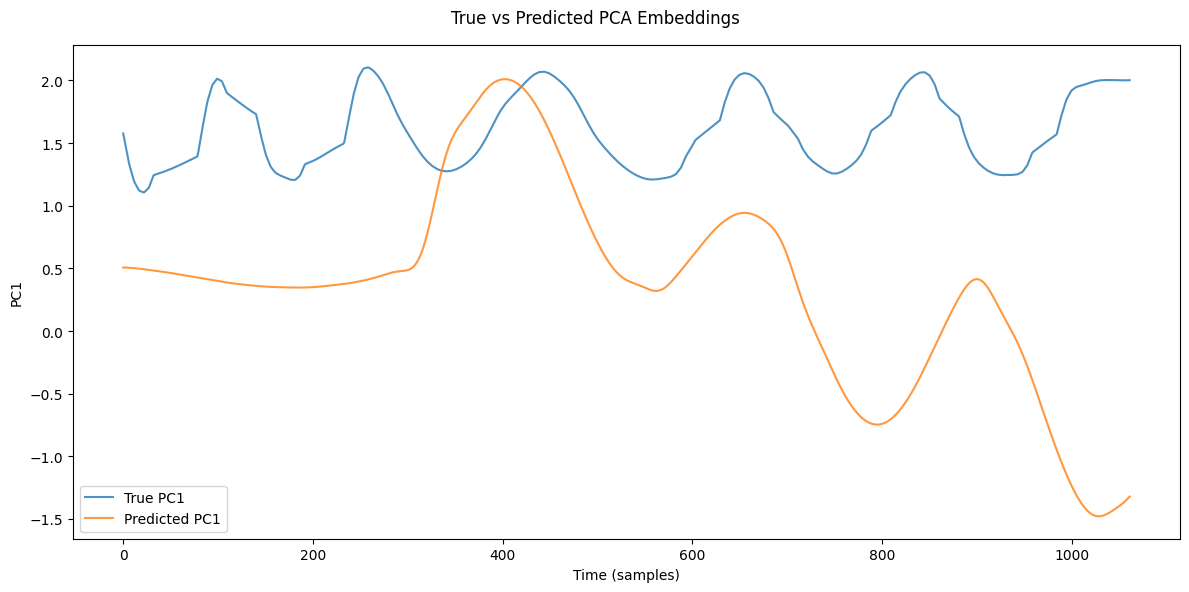

In [395]:
plt.close()
fig, ax = plt.subplots(Z.shape[1], 1, figsize=(12, 6), sharex=True)
if Z.shape[1] == 1:
    ax = [ax]

for i in range(Z.shape[1]):
    # PC1
    ax[i].plot(Z[:, i], label=f'True PC{i + 1}', alpha=0.8)
    ax[i].plot(0.3 * Z_hat[:, i], label=f'Predicted PC{i + 1}', alpha=0.8)
    ax[i].set_ylabel(f'PC{i + 1}')
    ax[i].legend()

    if i == Z.shape[1] - 1:
        ax[i].set_xlabel('Time (samples)')
    
plt.suptitle('True vs Predicted PCA Embeddings')
plt.tight_layout()
plt.show()

In [389]:
# 1. Check the learned dynamics
print("A eigenvalues:", np.sort(np.abs(np.linalg.eigvals(model.A))))
print("A singular values:", np.linalg.svd(model.A, compute_uv=False))
print("B singular values:", np.linalg.svd(model.B, compute_uv=False))
print("C singular values:", np.linalg.svd(model.C, compute_uv=False))

# 2. Check if the hidden state is actually moving
X, _ = _forward(U, model.A, model.B, model.C, model.x0_learned)
print("\nHidden state std dev over time:")
for i in range(model.d):
    print(f"  x[{i}] std: {np.std(X[:, i]):.4f}")

# 3. Check input-output correlation in PCA space
from scipy.stats import pearsonr
print()
for i in range(2):
    for j in range(Z.shape[1]):
        r, p = pearsonr(U[:, i], Z[:, j])
        print(f"Corr U{i+1} vs Z{j+1}: {r:.4f} (p={p:.4f})")
    print()

# 4. What frequency content is in Z vs Z_hat?
freqs = np.fft.rfftfreq(len(Z), d=1/160)
Z_fft = np.abs(np.fft.rfft(Z[:, 1], axis=0))
Z_hat_fft = np.abs(np.fft.rfft(Z_hat[:, 1], axis=0))

A eigenvalues: [0.86152895 0.86152895 0.86191802 0.86191802 0.87510176 0.87510176
 0.880129   0.89250128 0.89250128 0.91719652 0.97125281 0.97125281
 0.99968298 0.99968298 1.00034026 1.00034026]
A singular values: [1.12309097 1.07557082 0.9928315  0.98708162 0.96111565 0.93275911
 0.90921839 0.90822265 0.90422516 0.88388969 0.8737561  0.86381793
 0.85410446 0.84735139 0.83107334 0.80558367]
B singular values: [0.36841355 0.31867607]
C singular values: [0.21681812]

Hidden state std dev over time:
  x[0] std: 3800.8720
  x[1] std: 6257.1022
  x[2] std: 349.2934
  x[3] std: 540.2622
  x[4] std: 1146.8817
  x[5] std: 1046.9148
  x[6] std: 10925.9376
  x[7] std: 159.4707
  x[8] std: 482.9149
  x[9] std: 1077.6571
  x[10] std: 161.6994
  x[11] std: 242.0644
  x[12] std: 935.0426
  x[13] std: 472.1015
  x[14] std: 65.3555
  x[15] std: 94.4094

Corr U1 vs Z1: 0.2272 (p=0.0000)

Corr U2 vs Z1: 0.1805 (p=0.0000)



IndexError: index 1 is out of bounds for axis 1 with size 1

In [ ]:
print("A eigenvalues (raw):", np.linalg.eigvals(model.A))

In [390]:
from scipy.signal import correlate
for i in range(2):
    for j in range(Z.shape[1]):
        x = U[:, i] - U[:, i].mean()
        y = Z[:, j] - Z[:, j].mean()
        c = correlate(y, x, mode='full') / (np.std(x)*np.std(y)*len(x))
        lags = np.arange(-len(x)+1, len(x))
        peak_lag = lags[np.argmax(np.abs(c))]
        peak_corr = c[np.argmax(np.abs(c))]
        print(f"U{i+1}->Z{j+1}: peak corr {peak_corr:.3f} at lag {peak_lag}")

U1->Z1: peak corr -0.413 at lag -265
U2->Z1: peak corr -0.389 at lag -61


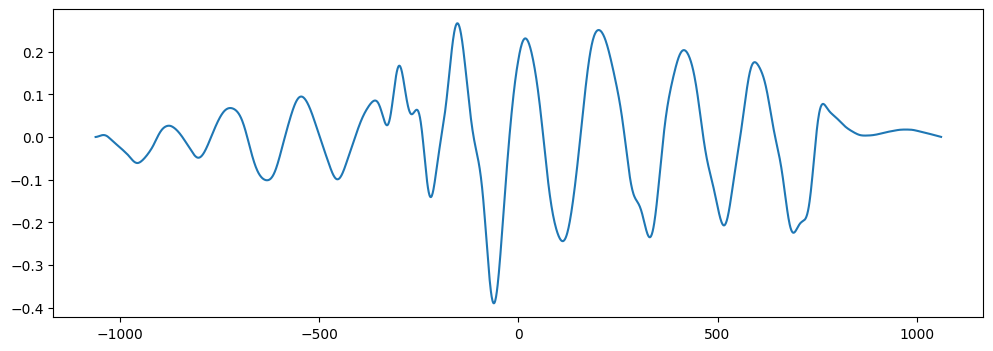

In [391]:
plt.plot(lags, c)

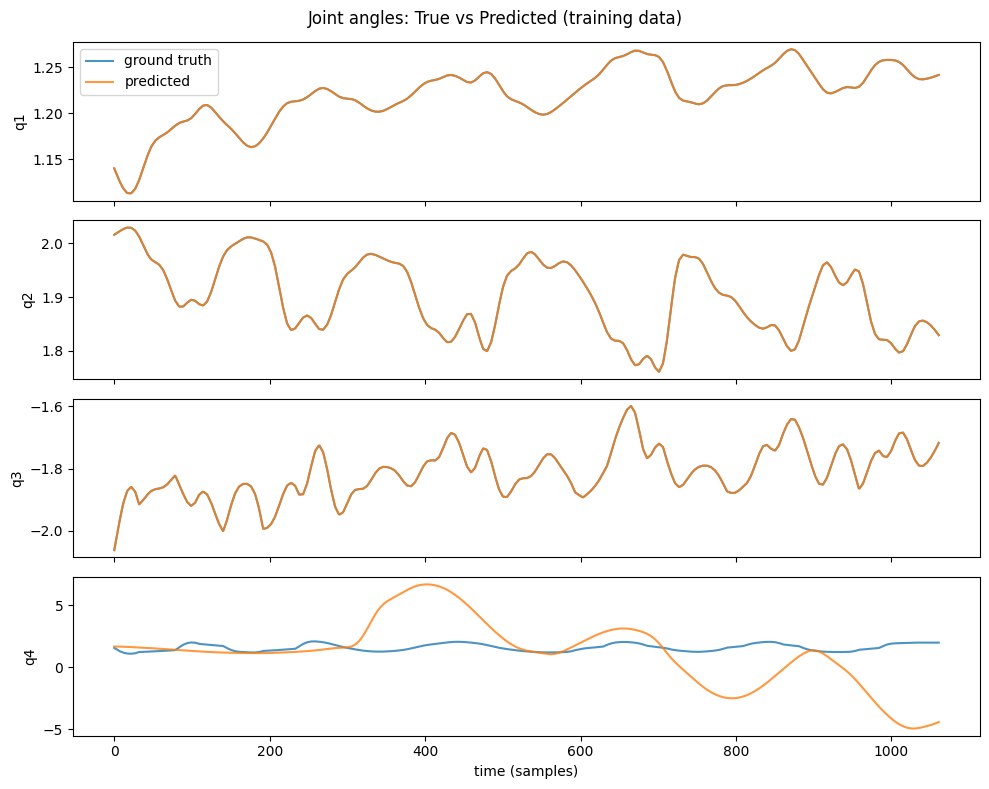

In [392]:
# Cell: Inverse PCA to get joint angles from predictions
q_hat = np.hstack([full_joint_data[:, 0:1], full_joint_data[:, 1:2], full_joint_data[:, 2:3], Z_hat]) #  pca_joint.inverse_transform(Z_hat)   # back to 4D joint angles
# q_hat columns: q1..q4

# Ground truth joint angles from df_model
q_gt = df_model[['q1', 'q2', 'q3', 'q4']].values

import matplotlib.pyplot as plt
fig, ax = plt.subplots(4,1,figsize=(10,8), sharex=True)
for i, col in enumerate(['q1', 'q2', 'q3', 'q4']):
    ax[i].plot(q_gt[:, i], label='ground truth', alpha=0.8)
    ax[i].plot(q_hat[:, i], label='predicted', alpha=0.8)
    ax[i].set_ylabel(col)
ax[0].legend()
ax[-1].set_xlabel('time (samples)')
plt.suptitle('Joint angles: True vs Predicted (training data)')
plt.tight_layout()
plt.show()

In [393]:
viz = ArmVisualizer(fk_func=forward_kinematics_fixed, L1=L1_FIXED, L2=L2_FIXED)

# Ground truth – elbow/wrist arrays relative to shoulder
#gt_elbow = pose_wide[['elbow_x','elbow_y','elbow_z']].values - pose_wide[['shoulder_x','shoulder_y','shoulder_z']].values
#gt_wrist = pose_wide[['bracelet_x','bracelet_y','bracelet_z']].values - pose_wide[['shoulder_x','shoulder_y','shoulder_z']].values
#viz.add_arm(name='Ground truth', color='green', dash='dash', elbow=gt_elbow, wrist=gt_wrist)
step = len(q_hat) // T
q_gt_downsampled = q_gt[::step][:T]

viz.add_arm(name='Ground truth', color='green', dash='dash',
            q1=q_gt_downsampled[:, 0], q2=q_gt_downsampled[:, 1],
            q3=q_gt_downsampled[:, 2], q4=q_gt_downsampled[:, 3])

T = gt_elbow.shape[0]
step = len(q_hat) // T
q_hat_downsampled = q_hat[::step][:T]

# FK arm from joint angles (all frames)
viz.add_arm(name='EMG-Reconstructed', color='yellow',
            q1=q_hat_downsampled[:, 0], q2=q_hat_downsampled[:, 1],
            q3=q_hat_downsampled[:, 2], q4=q_hat_downsampled[:, 3])

# Downsample for performance
viz.show(times=joint_angles['video_time_s'])

ValueError: Frame count mismatch: 233 vs 556